## Lab5

In this assignment you will use the `Weekly` data set, which is part of the `ISLP` package. This data is similar in nature to the `Smarket` data from the classification practice lab, except that it contains 1,089 weekly returns for 21 years, from the beginning of 1990 to the end of 2010.

In [1]:
# Import your libraries here
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize)

from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
     (LinearDiscriminantAnalysis as LDA,
      QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

Next load the `Weekly` data set.

In [2]:
Weekly = load_data('Weekly')
Weekly

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up
...,...,...,...,...,...,...,...,...,...
1084,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,Up
1085,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,Up
1086,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,Up
1087,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,Up


**(a) Produce some numerical and graphical summaries of the `Weekly` data. Do there appear to be any patterns? Do you notice any correlations?**

In [3]:
Weekly.corr(numeric_only=True)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


<Axes: >

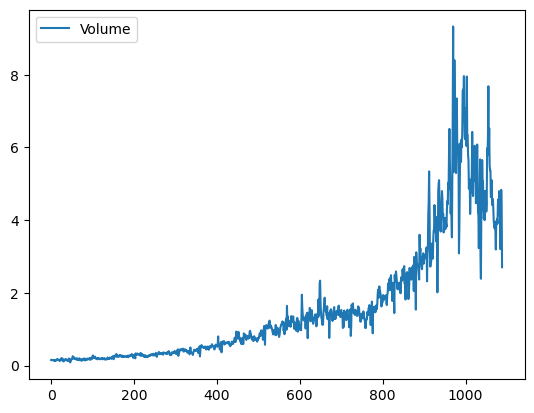

In [4]:
Weekly.plot(y='Volume')

Summarize and comment on your findings in this markdown cell:

Volume appears to have a positive correlation within this dataset

**(b) Use the full data set and the `statsmodels`'s logistic regression function to perform a logistic regression with `Direction` as the response and the five lag variables plus `Volume` as predictors. Also use ISLP `summary` function to print the results. Do any of the predictors appear to be statistically significant? If so, which ones?**

In [5]:
allvars = Weekly.columns.drop(['Today', 'Direction', 'Year'])
design = MS(allvars)
X = design.fit_transform(Weekly)
y = Weekly.Direction == 'Up'
glm = sm.GLM(y,
             X,
             family=sm.families.Binomial())
results = glm.fit()
print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Direction   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1082
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.18
Date:                Mon, 20 Oct 2025   Deviance:                       1486.4
Time:                        17:46:13   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.009000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2669      0.086      3.106      0.0

In [6]:
results.pvalues

intercept    0.001899
Lag1         0.118144
Lag2         0.029601
Lag3         0.546924
Lag4         0.293653
Lag5         0.583348
Volume       0.537675
dtype: float64

(Summarize and comment on your findings in this markdown cell)

There are 2 values that are statistically significant, intercept and Lag2, both of these are significant due to the p value below 0.05.

**(c) Construct the confusion matrix, and compute and interpret the various performance metrics (accuracy, precision, recall, FPR). Note that to obtain class predictions you need to manually set a threshold. Here use the default threshold of 0.5.**

In [7]:
probs = results.predict()
labels = np.array(['Down'] * len(y))
labels[probs>0.5] = 'Up'
confusionTable = confusion_table(labels, Weekly.Direction)
confusionTable

Truth,Down,Up
Predicted,,
Down,54,48
Up,430,557


In [8]:
# accuracy
print(f'Accuracy: {np.mean(labels == Weekly.Direction)*100:.2f}%')
# precision
precision = confusionTable.loc['Up', 'Up'] / confusionTable.loc[:, 'Up'].sum()
print(f'Precision: {precision * 100:.2f}%')
# recall
recall = confusionTable.loc['Up', 'Up'] / confusionTable.loc['Up', :].sum()
print(f'Recall: {recall * 100:.2f}%')
# FPR
fpr = confusionTable.loc['Down', 'Up'] / confusionTable.loc['Down', :].sum()
print(f'FPR: {fpr:.2f}')

Accuracy: 56.11%
Precision: 92.07%
Recall: 56.43%
FPR: 0.47


(Summarize and comment on your findings in this markdown cell)

Accuracy is slightly above random classification(50%). The precision is very high at 92%. Recall is moderate at 56%. FPR is high at 47%.

The model rarely mislabels things as negative, but misses many true positives.

## I will be creating vars to store values from the previous models to store for use in part i

In [9]:
probs_array = []

**(d) Now fit the `statsmodels`'s logistic regression model using a training data period from 1990 to 2008, with `Lag2` as the only predictor. Use the held-out data (that is, the data from 2009 and 2010) as your test set. Compute the confusion matrix and the overall fraction of correct predictions for the train and test sets (i.e. the train and test accuracy).**

In [10]:
# Logistic Regression model
X = MS(['Lag2']).fit(Weekly).transform(Weekly)
y = Weekly.Direction == 'Up'
X_train, X_test = X.loc[Weekly.Year < 2009], X.loc[Weekly.Year >= 2009]
y_train, y_test = y.loc[Weekly.Year < 2009], y.loc[Weekly.Year >= 2009]
glm = sm.GLM(y_train,
             X_train,
             family=sm.families.Binomial())
results = glm.fit()
p_hat = results.predict(exog=X_test)
probs_array.append(p_hat)
pred_bool = p_hat > 0.5
confusionTable = confusion_table(pred_bool, y_test)
confusionTable

Truth,False,True
Predicted,,
False,9,5
True,34,56


In [11]:
# overall fraction of correct predictions (train / test)
print(f'Training accuracy: {np.mean(y_train == (results.predict(X_train) > -.5)) * 100:.2f}%')
print(f'Testing accuracy: {np.mean(y_test == pred_bool) * 100:.2f}%')

Training accuracy: 55.23%
Testing accuracy: 62.50%


(Summarize and comment on your findings in this markdown cell)

This resulted in the testing set hacing a higher accuracy than the training set.
This means the model is generalizing decently well, however the model's overall accuracy is still relatively low at 62% testing accuracy. (still better than random)

**(e) Repeat (d) using LDA.**

In [12]:
# LDA model
X = MS(['Lag2']).fit(Weekly).transform(Weekly)
y = Weekly.Direction == 'Up'
X_train, X_test = X.loc[Weekly.Year < 2009], X.loc[Weekly.Year >= 2009]
y_train, y_test = y.loc[Weekly.Year < 2009], y.loc[Weekly.Year >= 2009]
lda = LDA(store_covariance=True)
X_train, X_test = [M.drop(columns=['intercept']) for M in [X_train, X_test]]
lda.fit(X_train, y_train)

# test set
pred_test = lda.predict(X_test)
conf_test = confusion_table(pred_test, y_test)
probs_array.append(pred_test)
conf_test



Truth,False,True
Predicted,,
False,9,5
True,34,56


In [13]:
# train set
pred_train = lda.predict(X_train)
conf_train = confusion_table(pred_train, y_train)
conf_train


Truth,False,True
Predicted,,
False,22,20
True,419,524


In [14]:
print(f'training accuracy: {np.mean(y_train == pred_train) * 100:.2f}%')
print(f'Testing accuracy: {np.mean(y_test == pred_test) * 100:.2f}%')

training accuracy: 55.43%
Testing accuracy: 62.50%


(Summarize and comment on your findings in this markdown cell)

Very similar results to the logistic regression model with the same accuracies on the testing set, but with slightly different results on the training set. This is likely because we used the same train test split.

**(f) Repeat (d) using QDA.**

In [15]:
# QDA model
qda = QDA(store_covariance=True)
qda.fit(X_train, y_train)

pred_train = qda.predict(X_train)
conf_train = confusion_table(pred_train, y_train)
conf_train


Truth,False,True
Predicted,,
False,0,0
True,441,544


In [16]:
pred_test = qda.predict(X_test)
conf_test = confusion_table(pred_test, y_test)
probs_array.append(pred_test)
conf_test

Truth,False,True
Predicted,,
False,0,0
True,43,61


In [17]:
print(f'training accuracy: {np.mean(y_train == pred_train) * 100:.2f}%')
print(f'Testing accuracy: {np.mean(y_test == pred_test) * 100:.2f}%')

training accuracy: 55.23%
Testing accuracy: 58.65%


(Summarize and comment on your findings in this markdown cell)

This model ended up predicting everything as being true. This ultimately highlighted that the overall dataset leans more to being true than false as shown by the training and testing sets being 55% and 59% acccurate respectively.

**(g) Repeat (d) using KNN with K = 1.**

In [18]:

X = MS(['Lag2']).fit(Weekly).transform(Weekly)
y = Weekly.Direction == 'Up'
X_train, X_test = X.loc[Weekly.Year < 2009], X.loc[Weekly.Year >= 2009]
y_train, y_test = y.loc[Weekly.Year < 2009], y.loc[Weekly.Year >= 2009]

knn1 = KNeighborsClassifier(n_neighbors=1)
X_train, X_test = [np.asarray(X) for X in [X_train, X_test]]
knn1.fit(X_train, y_train)
pred_train = knn1.predict(X_train)
confusion_table(pred_train, y_train)

Truth,False,True
Predicted,,
False,415,17
True,26,527


In [19]:
pred_test = knn1.predict(X_test)
confusion_table(pred_test, y_test)

Truth,False,True
Predicted,,
False,22,31
True,21,30


In [20]:
print(f'training accuracy: {np.mean(y_train == pred_train) * 100:.2f}%')
print(f'Testing accuracy: {np.mean(y_test == pred_test) * 100:.2f}%')

training accuracy: 95.63%
Testing accuracy: 50.00%


(Summarize and comment on your findings in this markdown cell)

The training accuracy is 96% which is expected to be high for the training set, but the testing accuracy is 50% which makes it no better than randomly assigning classes. (When k=1)

**(h) Repeat (d) using naive Bayes.**

In [21]:
np.unique(y_train, return_counts=True)

(array([False,  True]), array([441, 544], dtype=int64))

In [22]:

X = MS(['Lag2']).fit(Weekly).transform(Weekly)
y = Weekly.Direction == 'Up'
X_train, X_test = X.loc[Weekly.Year < 2009], X.loc[Weekly.Year >= 2009]
y_train, y_test = y.loc[Weekly.Year < 2009], y.loc[Weekly.Year >= 2009]

NB = GaussianNB()
NB.fit(X_train, y_train)
pred_train = NB.predict(X_train)
np.unique(pred_train, return_counts=True)
confusion_table(pred_train, y_train)

Truth,False,True
Predicted,,
False,0,0
True,441,544


In [23]:
pred_test = NB.predict(X_test)
confusion_table(pred_test, y_test)
probs_array.append(pred_test)

In [24]:
print(f'training accuracy: {np.mean(y_train == pred_train) * 100:.2f}%')
print(f'Testing accuracy: {np.mean(y_test == pred_test) * 100:.2f}%')

training accuracy: 55.23%
Testing accuracy: 58.65%


(Summarize and comment on your findings in this markdown cell)

This model also predicts everything will be positive resulting in a training accuracy of 55% and testing of 59%

**(i) Which of these methods appears to provide the best results on
this data?**

(Summarize and comment on your findings in this markdown cell)

The best modesl were Logistic regression and LDA which both had a testing accuracy of 62.50%

**(j) Now repeat part (d), this time using both `Lag1` and `Lag2` as predictors. Compare your findings with the ones from (d). Do you notice anything unexpected?**

In [25]:
# Logistic Regression model
X = MS(['Lag1','Lag2']).fit(Weekly).transform(Weekly)
y = Weekly.Direction == 'Up'
X_train, X_test = X.loc[Weekly.Year < 2009], X.loc[Weekly.Year >= 2009]
y_train, y_test = y.loc[Weekly.Year < 2009], y.loc[Weekly.Year >= 2009]
glm = sm.GLM(y_train,
             X_train,
             family=sm.families.Binomial())
results = glm.fit()
p_hat = results.predict(exog=X_test)
pred_bool = p_hat > 0.5
confusionTable = confusion_table(pred_bool, y_test)
confusionTable

Truth,False,True
Predicted,,
False,7,8
True,36,53


In [26]:
# overall fraction of correct predictions (train / test)
print(f'Training accuracy: {np.mean(y_train == (results.predict(X_train) > -.5)) * 100:.2f}%')
print(f'Testing accuracy: {np.mean(y_test == pred_bool) * 100:.2f}%')

Training accuracy: 55.23%
Testing accuracy: 57.69%


(Summarize and comment on your findings in this markdown cell)

The training accuracy with the added predictor stayed about the same as when it was only 'Lag2', but the testing average decreased by around 5% down to 58%.

**(k) Using again `Lag2` as the only predictor, experiment with different valus of $K$ in KNN by performing KNN parameter tuning. Which value of $K$ achieves the best overall performance on the held-out data?**

In [27]:

X = MS(['Lag2']).fit(Weekly).transform(Weekly)
y = Weekly.Direction == 'Up'
X_train, X_test = X.loc[Weekly.Year < 2009], X.loc[Weekly.Year >= 2009]
y_train, y_test = y.loc[Weekly.Year < 2009], y.loc[Weekly.Year >= 2009]

for K in range(1,10):
    knn = KNeighborsClassifier(n_neighbors=K)
    knn_pred = knn.fit(X_train, y_train).predict(X_test)
    C = confusion_table(knn_pred, y_test)
    print(f'K = {K}: # Testing accuracy: {np.mean(y_test == knn_pred) * 100:.2f}%')
    #print(C)
    #print('\n')
    if (K==4):
        probs_array.append(knn_pred)


K = 1: # Testing accuracy: 50.00%
K = 2: # Testing accuracy: 47.12%
K = 3: # Testing accuracy: 54.81%
K = 4: # Testing accuracy: 57.69%
K = 5: # Testing accuracy: 53.85%
K = 6: # Testing accuracy: 50.96%
K = 7: # Testing accuracy: 54.81%
K = 8: # Testing accuracy: 55.77%
K = 9: # Testing accuracy: 54.81%


(Summarize and comment on your findings in this markdown cell)

K=4 Has the highest accuracy score of 57.69%

**(l) Compare the overall performance of all classifiers from parts (d), (e), (f), (h), and (k) - that is, Logistic Regression, LDA, QDA, Naive Bayes, and KNN (using the best K from part (k)), all using `Lag2` as the only predictor, by plotting their ROC curves and computing their AUC (Area Under the Curve) values. Comment on your findings. How do the test accuracies obtained earlier (with a 0.5 threshold) and the AUCs differ as performance metrics?**

*Note: First convert the test labels to binary form (`Up = 1`, `Down = 0`) by using*

    y_test_num = (L_test == 'Up').astype(int)

*where `L_test` stands for the true labels in your test set.*

*You will also need `roc_curve` and `roc_auc_score` from `sklearn.metrics`. From these you can obtain the False/True Positive Rates (fpr, tpr) and the Area Under the Curve (auc) using:*

    fpr, tpr, _ = roc_curve(y_test_num, probs)
    auc = roc_auc_score(y_test_num, probs)
*where `probs` stands for the **test** probabilities of `"Up"` of each classifier. Since the FPR and TPR correspond to the horizontal and vertical axis in the ROC curve, you can plot each curve using `plt.plot(fpr, tpr)`. You can label each curve to improve legibility and add the random baseline with `plt.plot([0,1],[0,1],'k--',label='Random Guess')`* 

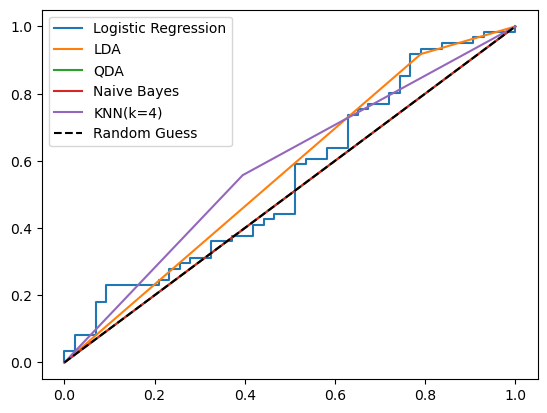

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
labels = ['Logistic Regression', 'LDA', 'QDA', 'Naive Bayes', 'KNN(k=4)']

for i in range(0,len(probs_array)):
    y_test_num = (y_test).astype(int)
    fpr, tpr, _ = roc_curve(y_test_num, probs_array[i])
    auc = roc_auc_score(y_test_num, probs_array[i])
    plt.plot(fpr, tpr, label=labels[i])

plt.plot([0,1],[0,1],'k--',label='Random Guess')
plt.legend()


(Summarize and comment on your findings in this markdown cell)

Overall none of these models massivly improve apon the random guess, which is expected when working with this dataset. However the LDA, Logistic regression, and KNN all appeared to be slightly better than guessing.

**(m) Open-ended section: Experiment with different combinations of predictors, including possible transformations and interactions, for each of the methods. Report the variables, method, and associated confusion matrix that appears to provide the best results on the held out data.**

(Summarize and comment on your findings in this markdown cell)